In [42]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sp500  = yf.download("^GSPC", start="2000-01-01", progress=False)   # S&P500
rates  = yf.download("^TNX", start="2000-01-01", progress=False)    # 미국 10년물 금리
vix    = yf.download("^VIX", start="2000-01-01", progress=False)    # 공포지수
oil    = yf.download("CL=F", start="2000-01-01", progress=False)    # 유가
dollar = yf.download("DX-Y.NYB", start="2000-01-01", progress=False) # 달러인덱스

# 하나로 합치기
df = pd.DataFrame({
    "SP500": sp500["Close"].squeeze(),
    "금리":  rates["Close"].squeeze(),
    "VIX":   vix["Close"].squeeze(),
    "유가":  oil["Close"].squeeze(),
    "달러":  dollar["Close"].squeeze()
})

df = df.dropna()

print(df.shape)
print(df.head())
print(df.tail())

(6473, 5)
                  SP500     금리        VIX         유가          달러
Date                                                            
2000-08-23  1505.969971  5.725  17.379999  32.049999  111.419998
2000-08-24  1508.310059  5.716  17.040001  31.629999  111.230003
2000-08-25  1506.449951  5.721  16.530001  32.049999  111.349998
2000-08-28  1514.089966  5.766  16.540001  32.869999  111.459999
2000-08-29  1509.839966  5.808  16.889999  32.720001  112.199997
                  SP500     금리        VIX         유가          달러
Date                                                            
2026-06-12  7431.459961  4.487  17.680000  84.879997   99.750000
2026-06-15  7554.290039  4.469  16.200001  80.750000   99.629997
2026-06-16  7511.350098  4.428  16.410000  76.050003   99.540001
2026-06-17  7420.100098  4.463  18.440001  76.790001  100.089996
2026-06-18  7500.580078  4.451  16.400000  76.599998  100.849998


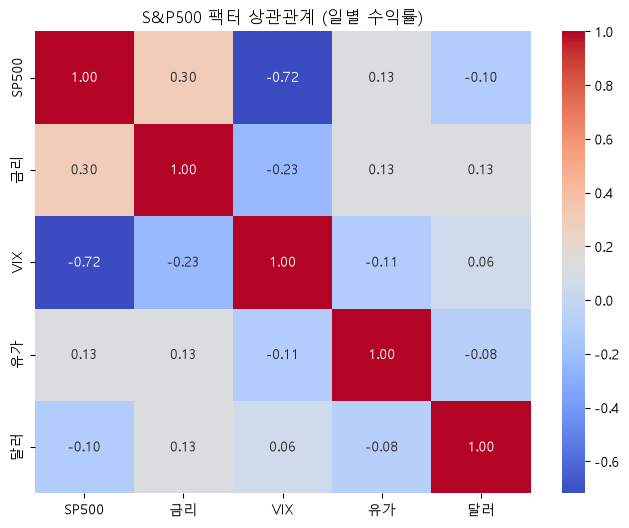

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_36972\3601622264.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


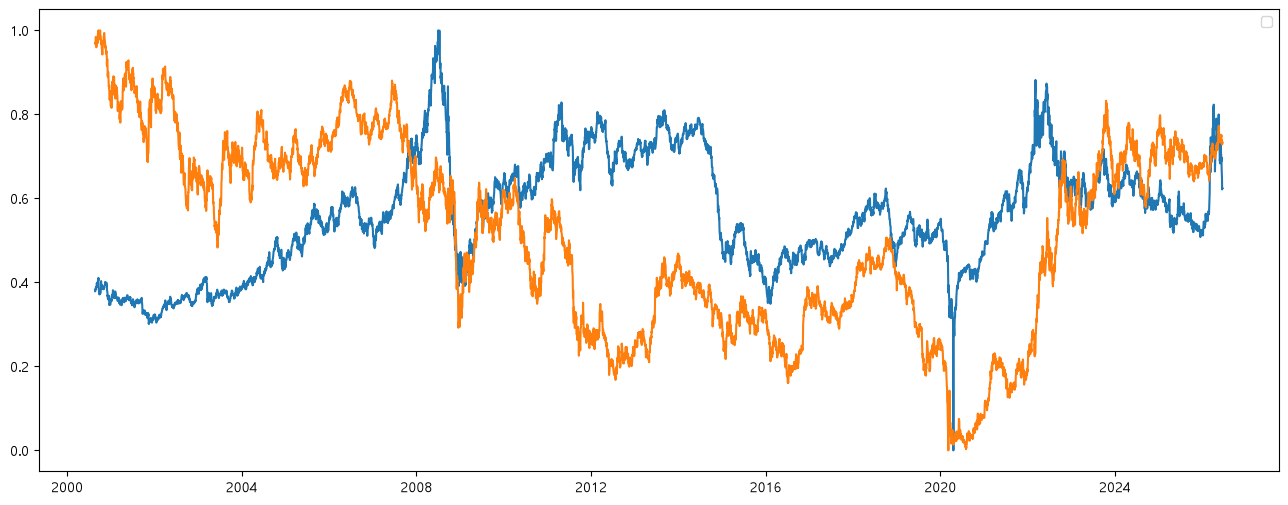

In [43]:
import seaborn as sns
# 가격 → 일별 수익률로 변환
df_returns = df.pct_change().dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(df_returns.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("S&P500 팩터 상관관계 (일별 수익률)")
plt.show()

import seaborn as sns
df_norm = (df - df.min()) / (df.max() - df.min())
# 그래프
plt.figure(figsize=(16, 6))
plt.plot(df_norm[["유가", "금리"]])


plt.legend()
plt.show()



In [44]:
df_ml = df_returns.copy()

# lag 피처 추가
for col in df_ml.columns:
    df_ml[f"{col}_lag1"] = df_ml[col].shift(1)
    df_ml[f"{col}_lag2"] = df_ml[col].shift(2)

df_ml = df_ml.dropna()

# 타겟: 내일 SP500 수익률
X = df_ml[[col for col in df_ml.columns if "lag" in col]]
y = df_ml["SP500"]

print(df_ml.shape)

(6470, 15)


In [45]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

split = int(len(df_ml) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
y_pred = model.predict(X_test)  

print(f"학습 R²: {r2_score(y_train, train_pred):.4f}")
print(f"테스트 R²: {r2_score(y_test, y_pred):.4f}")

correct_direction = ((y_pred > 0) == (y_test > 0)).mean()
print(f"방향 정확도: {correct_direction:.4f}")
strategy = y_test * (y_pred > 0).astype(int) * 2 - 1

학습 R²: 0.2680
테스트 R²: -0.0676
방향 정확도: 0.5216


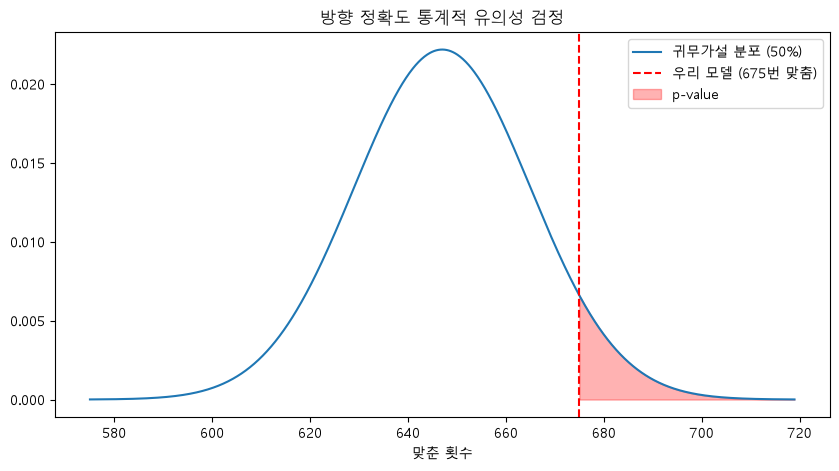

p-value: 0.0631


In [46]:
import numpy as np
from scipy import stats

n = len(y_test)
k = int(correct_direction * n)

# 이항분포 → 정규분포 근사
mu = n * 0.5
sigma = np.sqrt(n * 0.5 * 0.5)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

plt.figure(figsize=(10, 5))
plt.plot(x, stats.norm.pdf(x, mu, sigma), label="귀무가설 분포 (50%)")
plt.axvline(k, color='red', linestyle='--', label=f"우리 모델 ({k}번 맞춤)")

# 기각역 색칠
x_fill = np.linspace(k, mu + 4*sigma, 1000)
plt.fill_between(x_fill, stats.norm.pdf(x_fill, mu, sigma), alpha=0.3, color='red', label="p-value")

plt.title("방향 정확도 통계적 유의성 검정")
plt.xlabel("맞춘 횟수")
plt.legend()
plt.show()

p_value = stats.binomtest(k, n, p=0.5, alternative='greater').pvalue
print(f"p-value: {p_value:.4f}")

[*********************100%***********************]  1 of 1 completed
C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_36972\2300571120.py:26: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_ff = pd.concat([sp500_returns, ff3], axis=1).dropna()


시작: 1963-02-28 00:00:00
끝: 2026-04-30 00:00:00
총 759개월
               SP500  Mkt-RF     SMB     HML      RF
Date                                                
1963-02-28 -0.028852 -0.0240  0.0046  0.0215  0.0023
1963-03-31  0.035464  0.0308 -0.0258  0.0210  0.0023
1963-04-30  0.048520  0.0451 -0.0126  0.0100  0.0025
1963-05-31  0.014327  0.0176  0.0108  0.0255  0.0024
1963-06-30 -0.020198 -0.0200 -0.0032  0.0065  0.0023

=== 논문 발표 전 (1963~1991) ===
SMB 평균: 0.0025 (0.25%/월)
HML 평균: 0.0040 (0.40%/월)

=== 논문 발표 후 (1992~현재) ===
SMB 평균: 0.0006 (0.06%/월)
HML 평균: 0.0023 (0.23%/월)


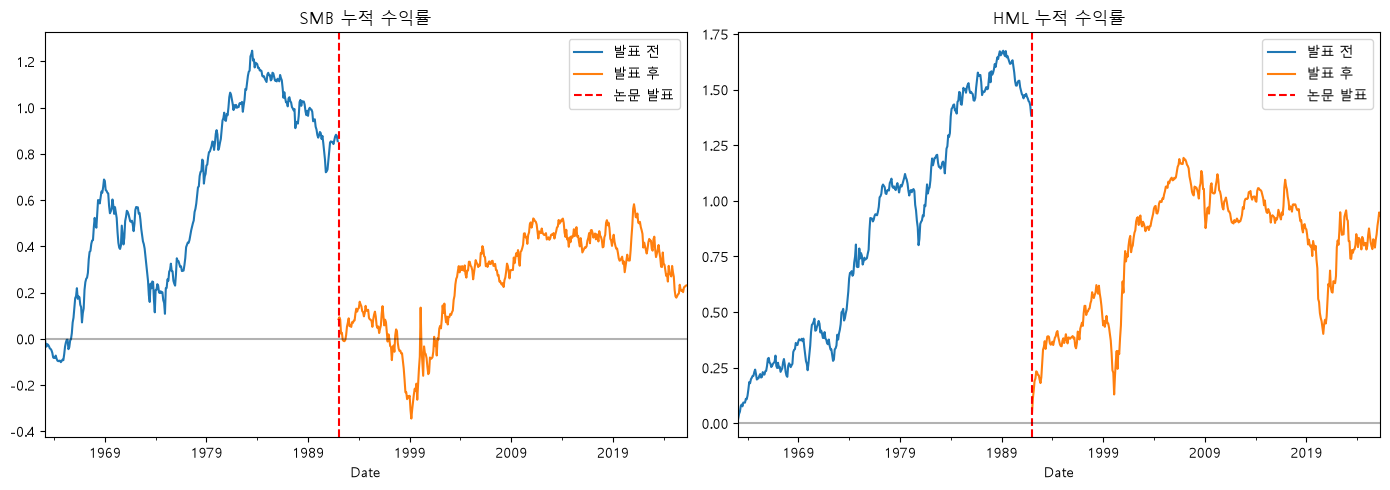

<Axes: xlabel='Date'>

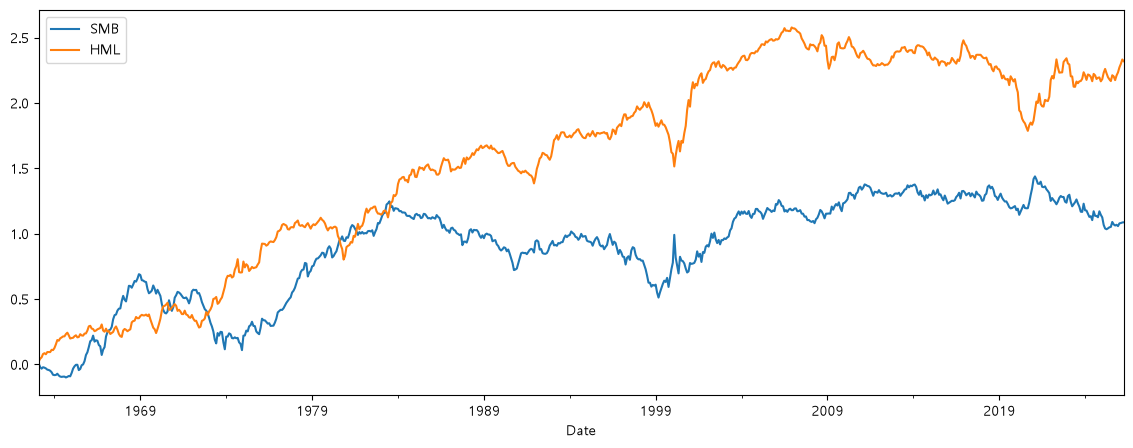

In [47]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas_datareader as pdr

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================
# 1. 데이터 수집
# ============================

# S&P500 (1963년부터)
sp500_raw = yf.download("^GSPC", start="1963-01-01")
sp500_monthly = sp500_raw["Close"].squeeze().resample('ME').last()
sp500_returns = sp500_monthly.pct_change().dropna()
sp500_returns.index = sp500_returns.index.to_period('M').to_timestamp('M')

# Fama-French 3 Factor
ff3 = pdr.get_data_famafrench('F-F_Research_Data_Factors', start='1963-01-01')[0]
ff3.index = pd.to_datetime(ff3.index.to_timestamp()).to_period('M').to_timestamp('M')
ff3 = ff3 / 100

# 합치기
df_ff = pd.concat([sp500_returns, ff3], axis=1).dropna()
df_ff.columns = ['SP500', 'Mkt-RF', 'SMB', 'HML', 'RF']

print(f"시작: {df_ff.index[0]}")
print(f"끝: {df_ff.index[-1]}")
print(f"총 {len(df_ff)}개월")
print(df_ff.head())

# ============================
# 2. 논문 발표 전/후 분석
# ============================

before = df_ff[df_ff.index < '1992-01-01']
after  = df_ff[df_ff.index >= '1992-01-01']

print("\n=== 논문 발표 전 (1963~1991) ===")
print(f"SMB 평균: {before['SMB'].mean():.4f} ({before['SMB'].mean()*100:.2f}%/월)")
print(f"HML 평균: {before['HML'].mean():.4f} ({before['HML'].mean()*100:.2f}%/월)")

print("\n=== 논문 발표 후 (1992~현재) ===")
print(f"SMB 평균: {after['SMB'].mean():.4f} ({after['SMB'].mean()*100:.2f}%/월)")
print(f"HML 평균: {after['HML'].mean():.4f} ({after['HML'].mean()*100:.2f}%/월)")

# ============================
# 3. 시각화
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SMB
before['SMB'].cumsum().plot(ax=axes[0], label='발표 전')
after['SMB'].cumsum().plot(ax=axes[0], label='발표 후')
axes[0].axvline(pd.Timestamp('1992-01-01'), color='red', linestyle='--', label='논문 발표')
axes[0].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[0].set_title('SMB 누적 수익률')
axes[0].legend()

# HML
before['HML'].cumsum().plot(ax=axes[1], label='발표 전')
after['HML'].cumsum().plot(ax=axes[1], label='발표 후')
axes[1].axvline(pd.Timestamp('1992-01-01'), color='red', linestyle='--', label='논문 발표')
axes[1].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[1].set_title('HML 누적 수익률')
axes[1].legend()

plt.tight_layout()
plt.show()
# 누적 SMB, HML 그래프
df_ff[['SMB', 'HML']].cumsum().plot(figsize=(14, 5))

SMB 발표 전 월평균: 0.246%
SMB 발표 후 월평균: 0.056%
HML 발표 전 월평균: 0.399%
HML 발표 후 월평균: 0.227%


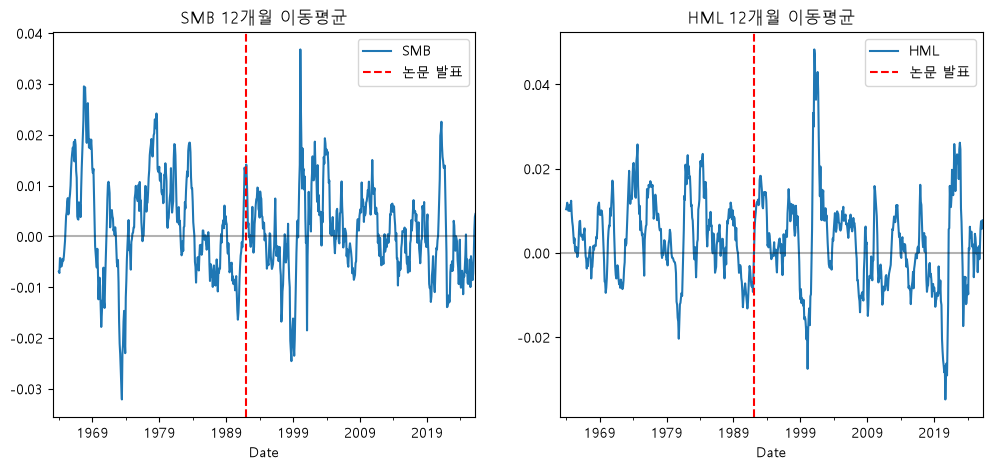

In [48]:
# 발표 전/후 평균 수익률 비교
print(f"SMB 발표 전 월평균: {before['SMB'].mean()*100:.3f}%")
print(f"SMB 발표 후 월평균: {after['SMB'].mean()*100:.3f}%")

print(f"HML 발표 전 월평균: {before['HML'].mean()*100:.3f}%")
print(f"HML 발표 후 월평균: {after['HML'].mean()*100:.3f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# rolling mean 으로 해당지점에서의 과거 12개월 평균 수익률을 계산
df_ff['SMB'].rolling(12).mean().plot(ax=axes[0])
axes[0].axvline(pd.Timestamp('1992-01-01'), color='red', linestyle='--', label='논문 발표')
axes[0].axhline(0, color='black', alpha=0.3)
axes[0].set_title('SMB 12개월 이동평균')
axes[0].legend()

df_ff['HML'].rolling(12).mean().plot(ax=axes[1])
axes[1].axvline(pd.Timestamp('1992-01-01'), color='red', linestyle='--', label='논문 발표')
axes[1].axhline(0, color='black', alpha=0.3)
axes[1].set_title('HML 12개월 이동평균')
axes[1].legend()

plt.show()

In [49]:
# FF5 데이터
ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='1963-01-01')[0]
ff5.index = pd.to_datetime(ff5.index.to_timestamp()).to_period('M').to_timestamp('M')
ff5 = ff5 / 100

# SP500 이랑 합치기
df_ff5 = pd.concat([sp500_returns, ff5], axis=1).dropna()
df_ff5.columns = ['SP500', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']

print(df_ff5.shape)
print(df_ff5.head())

(754, 7)
               SP500  Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                                
1963-07-31 -0.003460 -0.0039 -0.0048 -0.0081  0.0064 -0.0115  0.0027
1963-08-31  0.048749  0.0508 -0.0080  0.0170  0.0040 -0.0038  0.0025
1963-09-30 -0.011035 -0.0157 -0.0043  0.0000 -0.0078  0.0015  0.0027
1963-10-31  0.032218  0.0254 -0.0134 -0.0004  0.0279 -0.0225  0.0029
1963-11-30 -0.010539 -0.0086 -0.0085  0.0173 -0.0043  0.0227  0.0027


SMB
  FF3 발표 전  (1963~1992): 0.298%
  FF3~FF5 사이 (1992~2015): 0.219%
  FF5 발표 후  (2015~현재): -0.167%

HML
  FF3 발표 전  (1963~1992): 0.380%
  FF3~FF5 사이 (1992~2015): 0.363%
  FF5 발표 후  (2015~현재): -0.049%

RMW
  FF3 발표 전  (1963~1992): 0.201%
  FF3~FF5 사이 (1992~2015): 0.333%
  FF5 발표 후  (2015~현재): 0.243%

CMA
  FF3 발표 전  (1963~1992): 0.294%
  FF3~FF5 사이 (1992~2015): 0.345%
  FF5 발표 후  (2015~현재): -0.090%



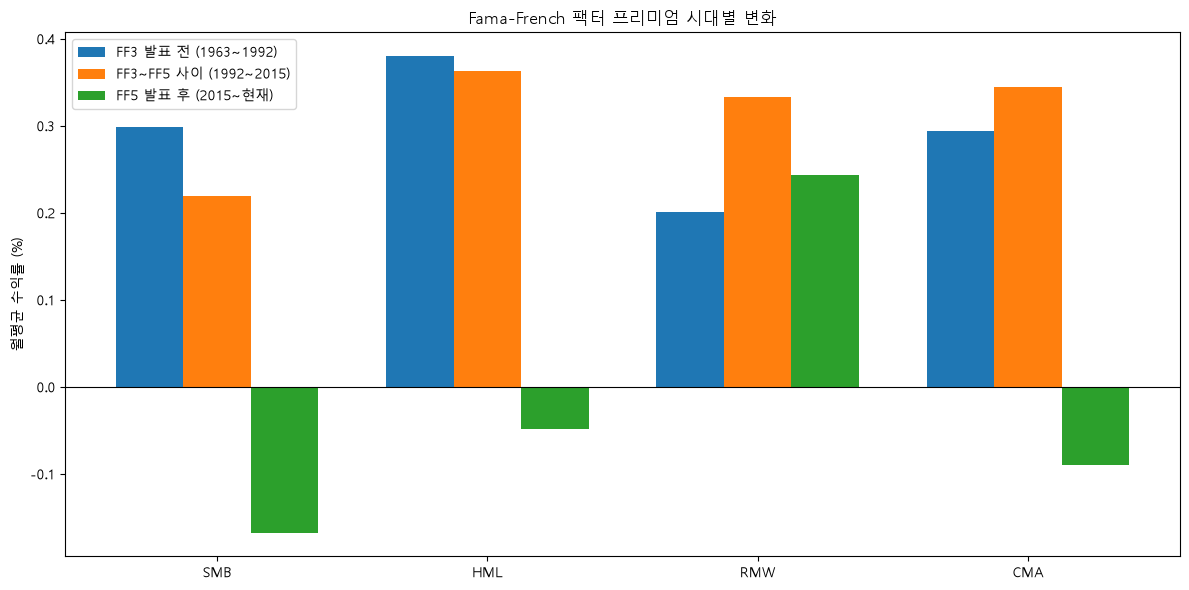

In [52]:
period1 = df_ff5[df_ff5.index < '1992-01-01']
period2 = df_ff5[(df_ff5.index >= '1992-01-01') & (df_ff5.index < '2015-01-01')]
period3 = df_ff5[df_ff5.index >= '2015-01-01']

for col in ['SMB', 'HML', 'RMW', 'CMA']:
    print(f"{col}")
    print(f"  FF3 발표 전  (1963~1992): {period1[col].mean()*100:.3f}%")
    print(f"  FF3~FF5 사이 (1992~2015): {period2[col].mean()*100:.3f}%")
    print(f"  FF5 발표 후  (2015~현재): {period3[col].mean()*100:.3f}%")
    print()

import matplotlib.pyplot as plt
import numpy as np

factors = ['SMB', 'HML', 'RMW', 'CMA']
p1 = [period1[col].mean()*100 for col in factors]
p2 = [period2[col].mean()*100 for col in factors]
p3 = [period3[col].mean()*100 for col in factors]

x = np.arange(len(factors))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, p1, width, label='FF3 발표 전 (1963~1992)')
ax.bar(x,         p2, width, label='FF3~FF5 사이 (1992~2015)')
ax.bar(x + width, p3, width, label='FF5 발표 후 (2015~현재)')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(factors)
ax.set_ylabel('월평균 수익률 (%)')
ax.set_title('Fama-French 팩터 프리미엄 시대별 변화')
ax.legend()

plt.tight_layout()
plt.show()

<Figure size 1400x500 with 0 Axes>

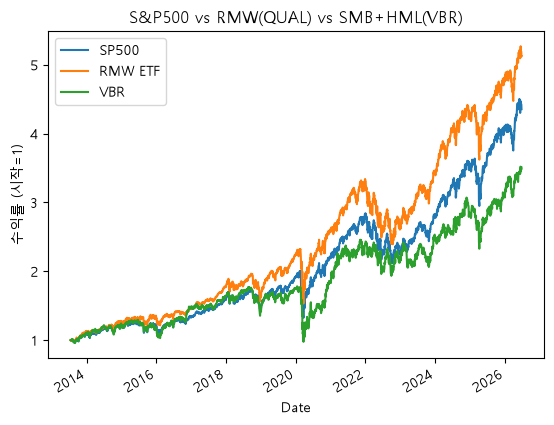

In [53]:
tickers = {
    "SP500":  "^GSPC",
    "RMW ETF": "QUAL",   # iShares MSCI USA Quality ETF
    "VBR":    "VBR",     # Vanguard Small Cap Value (SMB+HML)
}

import yfinance as yf
import pandas as pd

data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start="2013-01-01", progress=False)["Close"].squeeze()
    data[name] = df

df_compare = pd.DataFrame(data).dropna()

# 정규화 (같은 시작점)
df_norm = df_compare / df_compare.iloc[0]

plt.figure(figsize=(14, 5))
df_norm.plot()
plt.title("S&P500 vs RMW(QUAL) vs SMB+HML(VBR)")
plt.ylabel("수익률 (시작=1)")
plt.show()

In [54]:
# 일별 수익률
returns = df_compare.pct_change().dropna()

# 연간 변동성 (일별 표준편차 * sqrt(252))
vol = returns.std() * (252 ** 0.5)
print("연간 변동성:")
print(vol)

# 샤프 지수 (수익률 / 변동성)
annual_returns = (df_norm.iloc[-1] ** (252/len(df_norm))) - 1
sharpe = annual_returns / vol
print("\n샤프 지수:")
print(sharpe)

연간 변동성:
SP500      0.171326
RMW ETF    0.171452
VBR        0.203098
dtype: float64

샤프 지수:
SP500      0.704740
RMW ETF    0.787154
VBR        0.502753
dtype: float64


KODEX200: 4024일
KODEX코스닥: 2601일
KODEX가치: 4024일

공통 기간: 2015-10-01 ~ 2026-06-25
총 2601일


<Figure size 1400x500 with 0 Axes>

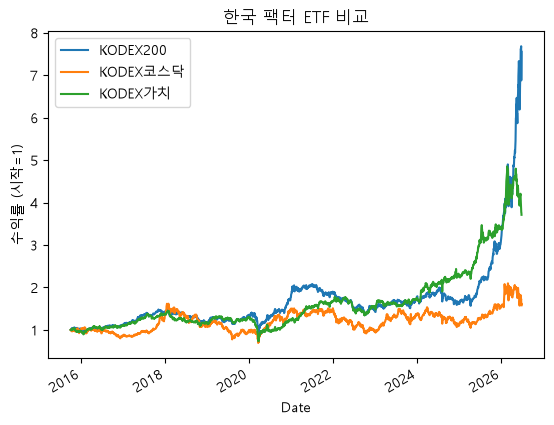

In [56]:
tickers_kr = {
    "KODEX200":    "069500.KS",
    "KODEX코스닥": "229200.KS",
    "KODEX가치":   "104530.KS",
}

data_kr = {}
for name, ticker in tickers_kr.items():
    df = yf.download(ticker, start="2010-01-01", progress=False)["Close"].squeeze()
    data_kr[name] = df
    print(f"{name}: {len(df)}일")

df_kr = pd.DataFrame(data_kr).dropna()
print(f"\n공통 기간: {df_kr.index[0].date()} ~ {df_kr.index[-1].date()}")
print(f"총 {len(df_kr)}일")
# 정규화
df_kr_norm = df_kr / df_kr.iloc[0]

plt.figure(figsize=(14, 5))
df_kr_norm.plot()
plt.title("한국 팩터 ETF 비교")
plt.ylabel("수익률 (시작=1)")
plt.show()

            Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                      
1990-07-31  0.0420 -0.0282 -0.0146  0.0234  0.0091  0.0068
1990-08-31 -0.0868  0.0361  0.0173  0.0027  0.0067  0.0066
1990-09-30 -0.0880  0.0365 -0.0006  0.0097  0.0417  0.0060
1990-10-31 -0.0195 -0.0476 -0.0148  0.0068 -0.0273  0.0068
1990-11-30 -0.0298 -0.0158 -0.0077  0.0265  0.0056  0.0057
시작: 1990-07-31 00:00:00
끝: 2026-04-30 00:00:00


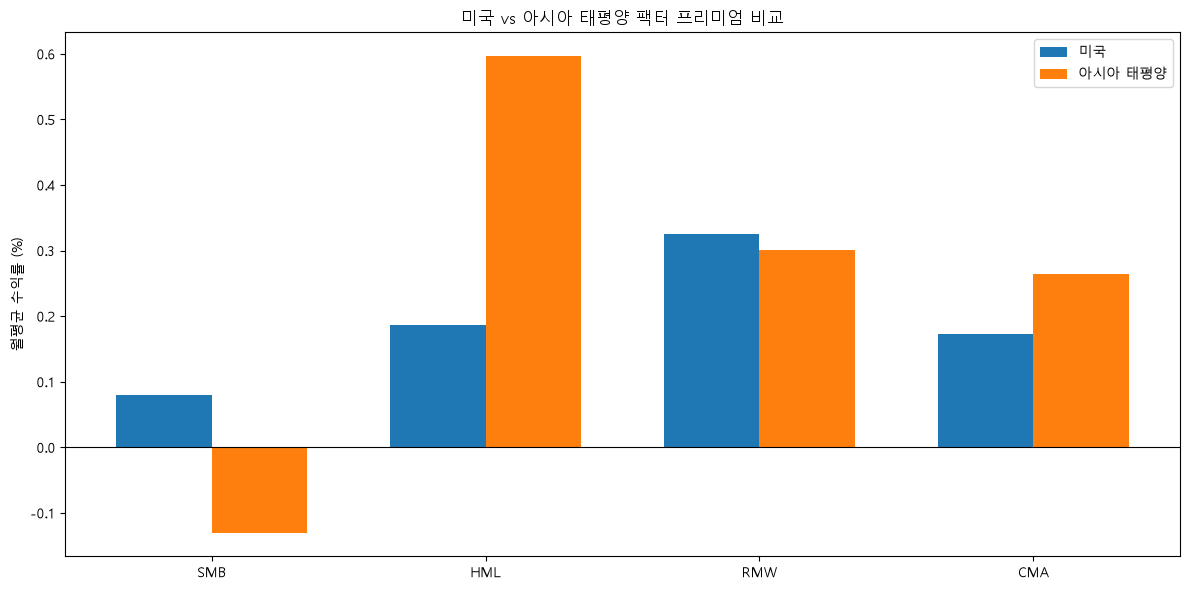

SMB  미국: 0.080%  아시아: -0.130%
HML  미국: 0.186%  아시아: 0.596%
RMW  미국: 0.326%  아시아: 0.301%
CMA  미국: 0.173%  아시아: 0.264%


In [58]:
# 아시아 태평양 (한국 포함) FF 데이터
ff_asia = pdr.get_data_famafrench('Asia_Pacific_ex_Japan_5_Factors', start='1990-01-01')[0]
ff_asia.index = pd.to_datetime(ff_asia.index.to_timestamp()).to_period('M').to_timestamp('M')
ff_asia = ff_asia / 100

print(ff_asia.head())
print(f"시작: {ff_asia.index[0]}")
print(f"끝: {ff_asia.index[-1]}")

# 미국 FF5 (df_ff5) vs 아시아 FF5 (ff_asia)
# 공통 기간 맞추기
common_start = max(df_ff5.index[0], ff_asia.index[0])
us = df_ff5[df_ff5.index >= common_start]
asia = ff_asia[ff_asia.index >= common_start]

# 팩터별 평균 수익률 비교
factors = ['SMB', 'HML', 'RMW', 'CMA']

us_means = [us[col].mean()*100 for col in factors]
asia_means = [asia[col].mean()*100 for col in factors]

x = np.arange(len(factors))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, us_means, width, label='미국')
ax.bar(x + width/2, asia_means, width, label='아시아 태평양')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(factors)
ax.set_ylabel('월평균 수익률 (%)')
ax.set_title('미국 vs 아시아 태평양 팩터 프리미엄 비교')
ax.legend()

plt.tight_layout()
plt.show()

# 숫자로도
for i, col in enumerate(factors):
    print(f"{col}  미국: {us_means[i]:.3f}%  아시아: {asia_means[i]:.3f}%")

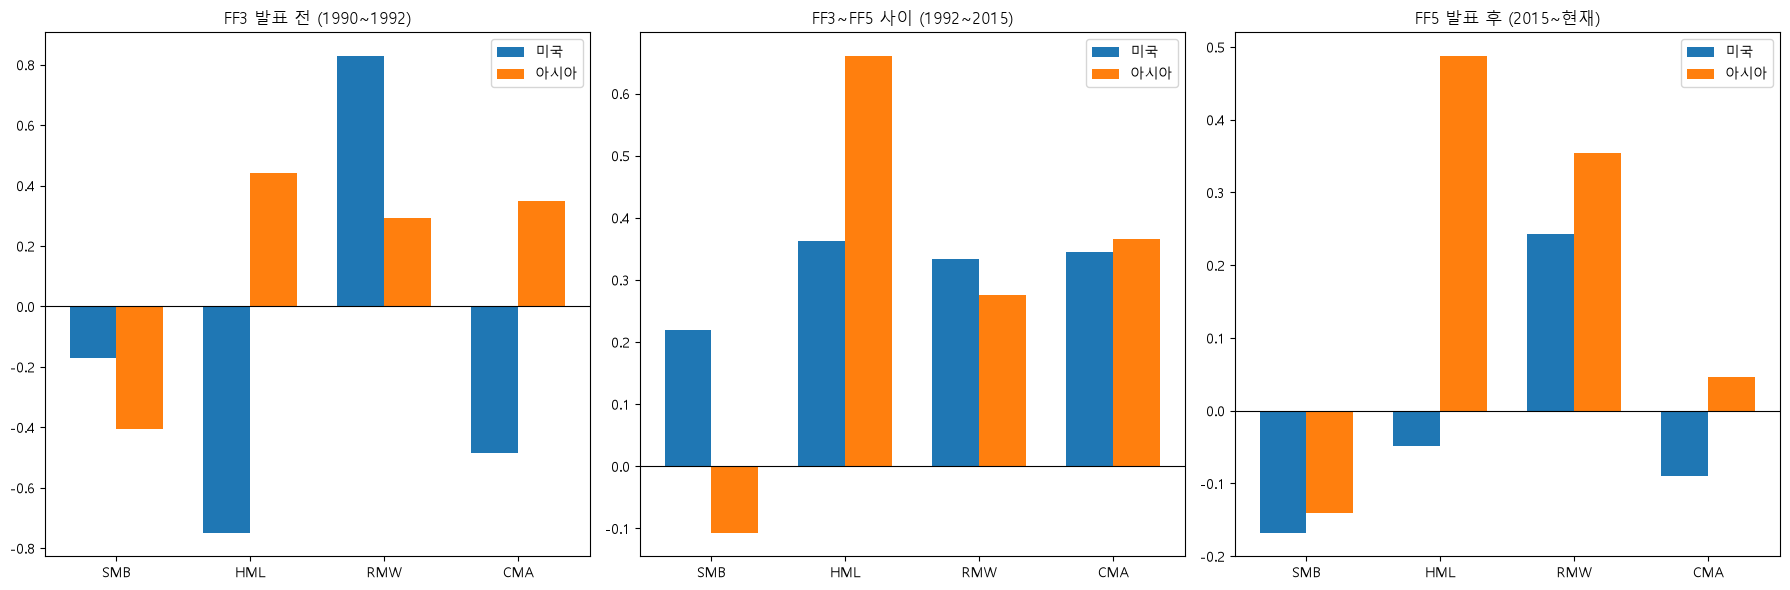

In [59]:
periods = {
    'FF3 발표 전 (1990~1992)': ('1990-01-01', '1992-01-01'),
    'FF3~FF5 사이 (1992~2015)': ('1992-01-01', '2015-01-01'),
    'FF5 발표 후 (2015~현재)': ('2015-01-01', '2026-12-31')
}

factors = ['SMB', 'HML', 'RMW', 'CMA']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (period_name, (start, end)) in enumerate(periods.items()):
    us_period = us[(us.index >= start) & (us.index < end)]
    asia_period = asia[(asia.index >= start) & (asia.index < end)]
    
    us_means = [us_period[col].mean()*100 for col in factors]
    asia_means = [asia_period[col].mean()*100 for col in factors]
    
    x = np.arange(len(factors))
    width = 0.35
    
    axes[idx].bar(x - width/2, us_means, width, label='미국')
    axes[idx].bar(x + width/2, asia_means, width, label='아시아')
    axes[idx].axhline(0, color='black', linewidth=0.8)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(factors)
    axes[idx].set_title(period_name)
    axes[idx].legend()

plt.tight_layout()
plt.show()